In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split


In [5]:
# Load data (replace the path with your dataset path)
data = pd.read_csv('exported_metrics.csv')

# Convert timestamp to datetime (if necessary)
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Ensure the data is sorted by timestamp
data.sort_values('timestamp', inplace=True)

# Select relevant columns
data = data[['timestamp', 'network_sent_bytes', 'network_recv_bytes', 'active_connections']]

# Handle missing values (optional: you can drop or fill)
data.fillna(method='ffill', inplace=True)  # Forward fill missing values

# Normalize the features using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[['network_sent_bytes', 'network_recv_bytes', 'active_connections']])

# Create a function to prepare data in sequences for LSTM
def create_dataset(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size, 0])  # Predict 'network_sent_bytes' as the target
    return np.array(X), np.array(y)

# Prepare the dataset
window_size = 10  # Look back over the last 10 timesteps
X, y = create_dataset(data_scaled, window_size)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


<ipython-input-5-e473ebbf3afa>:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)  # Forward fill missing values


In [6]:
# Build the LSTM model
model = Sequential()

# First LSTM layer
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

# Second LSTM layer
model.add(LSTM(units=32))

# Fully connected layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0242 - val_loss: 6.8210e-04
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5.0503e-05 - val_loss: 4.4828e-04
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.0161e-05 - val_loss: 5.4249e-04
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.5054e-05 - val_loss: 3.1915e-04
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.2740e-05 - val_loss: 3.4557e-04
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 2.3790e-05 - val_loss: 5.9860e-04
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 2.4187e-05 - val_loss: 1.6565e-04
Epoch 8/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.8500e-05 - val_loss: 2.1472e-04
Epoch 9/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.3524e-05 - val_loss: 1.4720e-04
Epoch 10/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 2.5138e-05 - val_loss: 1.1355e-04
Epoch 11/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step

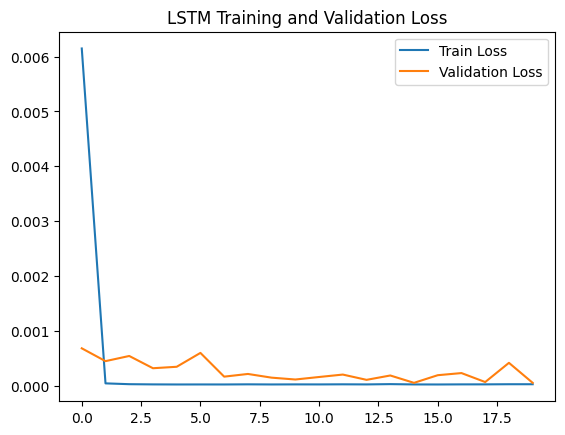

In [7]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.show()


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
Root Mean Squared Error (RMSE): 52570.05575601548


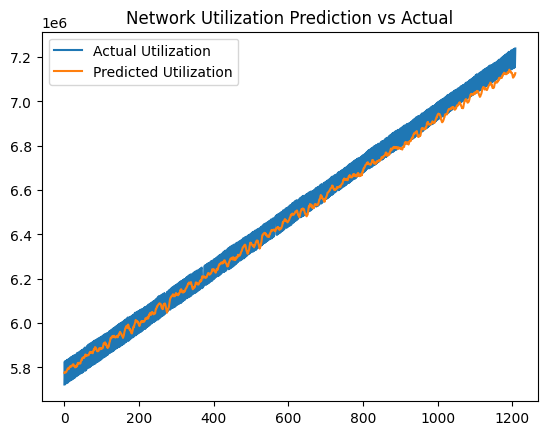

In [8]:
# Predict on the test set
y_pred = model.predict(X_test)

# Inverse transform the scaled predictions
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((y_pred.shape[0], 2))), axis=1))[:, 0]
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 2))), axis=1))[:, 0]

# Calculate RMSE (Root Mean Squared Error)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Plot actual vs predicted
plt.plot(y_test_rescaled, label='Actual Utilization')
plt.plot(y_pred_rescaled, label='Predicted Utilization')
plt.title('Network Utilization Prediction vs Actual')
plt.legend()
plt.show()
